# Business Sales Performance Analytics
## Exploratory Data Analysis (EDA) & KPI Dashboard

This notebook performs a comprehensive data analysis of the retail company's sales data to identify revenue trends, top-performing products, profitable categories, and regional sales performance. The goal is to provide data-driven insights and actionable business recommendations.

### Key Focus Areas:
1. **KPI Analysis:** Calculation of high-level business metrics (Total Revenue, Total Profit, Profit Margin, etc.).
2. **Exploratory Data Analysis (EDA):** Visualizing monthly trends, regional splits, product performance, and distributions.
3. **Business Questions:** Answering specific managerial questions to guide strategic decisions.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime

# Set styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16

# Create images folder if not exists
os.makedirs("../images", exist_ok=True)

# Load cleaned dataset
df = pd.read_csv("../data/sales_data.csv")
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['YearMonth'] = df['Order Date'].dt.to_period('M')
df['Year'] = df['Order Date'].dt.year

print(f"Loaded dataset: {df.shape[0]} orders, {df.shape[1]} columns.")
df.head()

Loaded dataset: 8000 orders, 13 columns.


,Order ID,Order Date,Product Name,Category,Sub-Category,Sales Revenue,Quantity Sold,Profit,Customer Segment,Region,State/City,YearMonth,Year
0,CA-2024-100847,2022-01-01,Executive Leather Chair,Furniture,Chairs,29058.30,1,3486.83,Home Office,South,"Florida, Miami",2022-01,2022
1,CA-2024-101546,2022-01-01,5-Shelf Oak Bookcase,Furniture,Bookcases,300079.03,10,-45011.73,Corporate,West,"Oregon, Portland",2022-01,2022
2,CA-2023-101631,2022-01-01,Label Printer XL,Technology,Machines,458418.13,5,22920.45,Consumer,East,"New York, New York City",2022-01,2022
3,CA-2025-100141,2022-01-02,Heavy Duty D-Ring Binder,Office Supplies,Binders,4875.42,2,2193.69,Home Office,West,"California, Los Angeles",2022-01,2022
4,CA-2023-101929,2022-01-02,Anti-Fatigue Floor Mat,Furniture,Furnishings,17133.69,5,3427.07,Consumer,West,"California, Los Angeles",2022-01,2022


## 1. Key Performance Indicators (KPIs)
We calculate the standard business metrics:
* **Total Sales (Revenue)**
* **Total Profit**
* **Profit Margin (%)**
* **Total Orders**
* **Average Order Value (AOV)**
* **Annual Growth Rate (YoY)**


In [2]:
# Calculate KPIs
total_sales = df['Sales Revenue'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100
total_orders = df['Order ID'].nunique()
avg_order_value = total_sales / total_orders

print("=== KEY PERFORMANCE INDICATORS ===")
print(f"Total Sales Revenue: ₹{total_sales:,.2f}")
print(f"Total Profit:        ₹{total_profit:,.2f}")
print(f"Overall Net Margin:  {profit_margin:.2f}%")
print(f"Total Unique Orders: {total_orders:,}")
print(f"Average Order Value: ₹{avg_order_value:,.2f}")

# Calculate Year-over-Year (YoY) Growth
yearly_sales = df.groupby('Year')['Sales Revenue'].sum()
yearly_growth = yearly_sales.pct_change() * 100

print("\n=== YEARLY SALES & GROWTH (YoY) ===")
for yr, sales in yearly_sales.items():
    growth = yearly_growth.get(yr, np.nan)
    growth_str = f"{growth:+.2f}%" if not pd.isna(growth) else "N/A"
    print(f"Year {yr}: Sales = ₹{sales:,.2f} | Growth = {growth_str}")


=== KEY PERFORMANCE INDICATORS ===
Total Sales Revenue: ₹745,546,068.25
Total Profit:        ₹58,962,017.25
Overall Net Margin:  7.91%
Total Unique Orders: 8,000
Average Order Value: ₹93,193.26

=== YEARLY SALES & GROWTH (YoY) ===
Year 2022: Sales = ₹184,361,429.32 | Growth = N/A
Year 2023: Sales = ₹175,645,712.20 | Growth = -4.73%
Year 2024: Sales = ₹182,954,545.29 | Growth = +4.16%
Year 2025: Sales = ₹202,584,381.44 | Growth = +10.73%


## 2. Monthly Revenue & Profit Trends
Analyzing sales over time helps identify seasonality, business cycles, and overall growth direction.


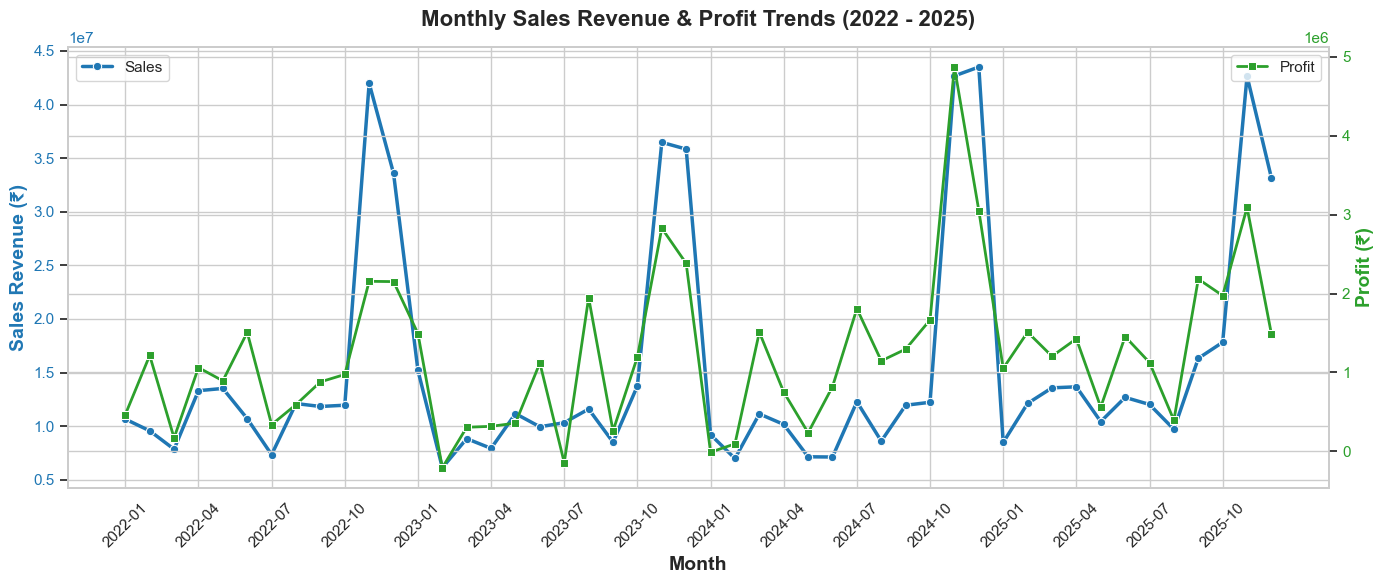

In [3]:
# Group by YearMonth
monthly_df = df.groupby('YearMonth').agg(
    Sales_Revenue=('Sales Revenue', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()

monthly_df['YearMonth_Str'] = monthly_df['YearMonth'].astype(str)

# Matplotlib/Seaborn trend plot
fig, ax1 = plt.subplots(figsize=(14, 6))

color = '#1f77b4'
ax1.set_xlabel('Month', fontweight='bold')
ax1.set_ylabel('Sales Revenue (₹)', color=color, fontweight='bold')
sns.lineplot(data=monthly_df, x='YearMonth_Str', y='Sales_Revenue', marker='o', color=color, linewidth=2.5, ax=ax1, label='Sales')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(range(0, len(monthly_df), 3))
ax1.set_xticklabels(monthly_df['YearMonth_Str'].iloc[::3], rotation=45)

ax2 = ax1.twinx()  
color = '#2ca02c'
ax2.set_ylabel('Profit (₹)', color=color, fontweight='bold')
sns.lineplot(data=monthly_df, x='YearMonth_Str', y='Profit', marker='s', color=color, linewidth=2, ax=ax2, label='Profit')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Monthly Sales Revenue & Profit Trends (2022 - 2025)', fontsize=16, fontweight='bold', pad=15)
fig.tight_layout()
plt.savefig('../images/monthly_trends.png', dpi=300)
plt.show()


## 3. Regional Sales Performance
Identifying which regions generate the highest sales and profit helps allocate marketing budgets and sales resources.


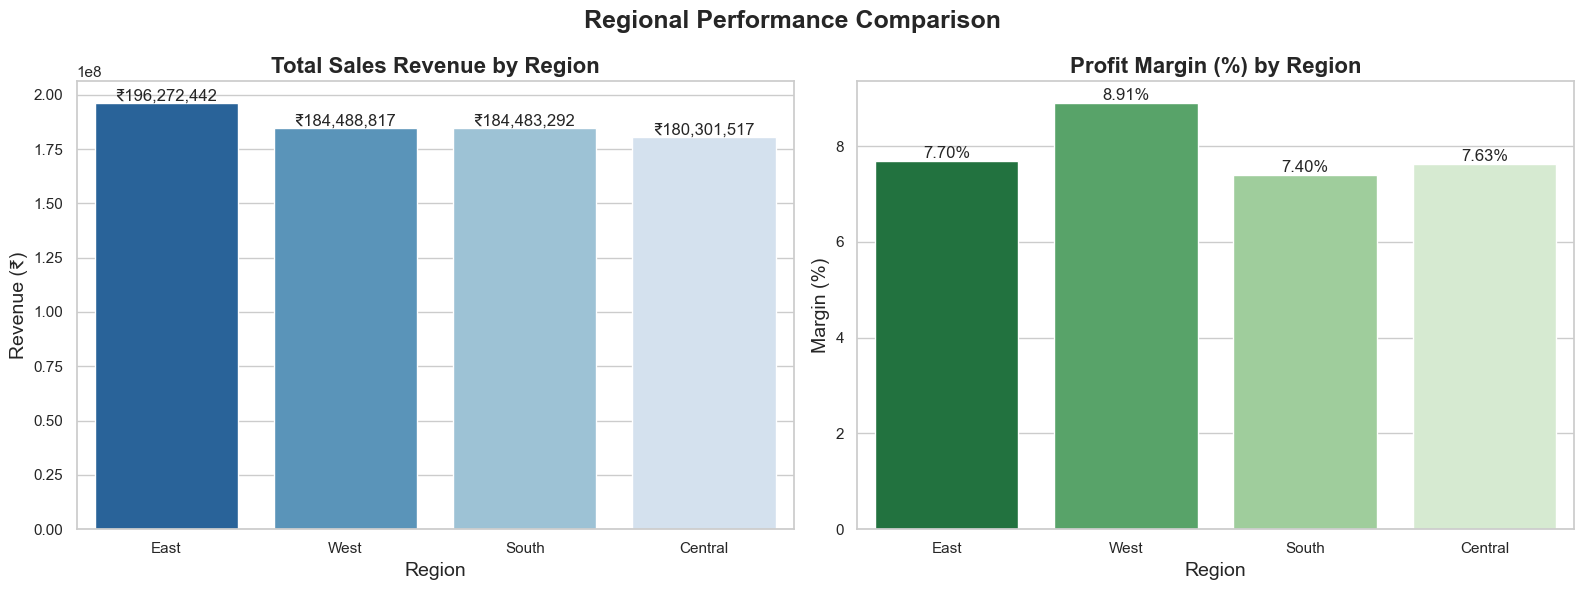

,Region,Sales_Revenue,Profit,Orders,Profit_Margin
1,East,1.962724e+08,15107344.60,2045,7.697130
3,West,1.844888e+08,16431289.22,1998,8.906388
2,South,1.844833e+08,13659794.72,2001,7.404353
0,Central,1.803015e+08,13763588.71,1956,7.633651


In [4]:
# Regional performance
region_df = df.groupby('Region').agg(
    Sales_Revenue=('Sales Revenue', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'count')
).reset_index()
region_df['Profit_Margin'] = (region_df['Profit'] / region_df['Sales_Revenue']) * 100
region_df = region_df.sort_values(by='Sales_Revenue', ascending=False)

# Visualizing Regional Performance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sales by Region
sns.barplot(data=region_df, x='Region', y='Sales_Revenue', hue='Region', palette='Blues_r', ax=axes[0], legend=False)
axes[0].set_title('Total Sales Revenue by Region', fontweight='bold')
axes[0].set_ylabel('Revenue (₹)')
axes[0].set_xlabel('Region')
for p in axes[0].patches:
    axes[0].annotate(f"₹{p.get_height():,.0f}", (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Profit Margin by Region
sns.barplot(data=region_df, x='Region', y='Profit_Margin', hue='Region', palette='Greens_r', ax=axes[1], legend=False)
axes[1].set_title('Profit Margin (%) by Region', fontweight='bold')
axes[1].set_ylabel('Margin (%)')
axes[1].set_xlabel('Region')
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.suptitle('Regional Performance Comparison', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/regional_performance.png', dpi=300)
plt.show()

region_df


## 4. Product Category and Sub-Category Performance
Understanding which categories drive revenue versus profit highlights areas for inventory expansion or product line retirement.


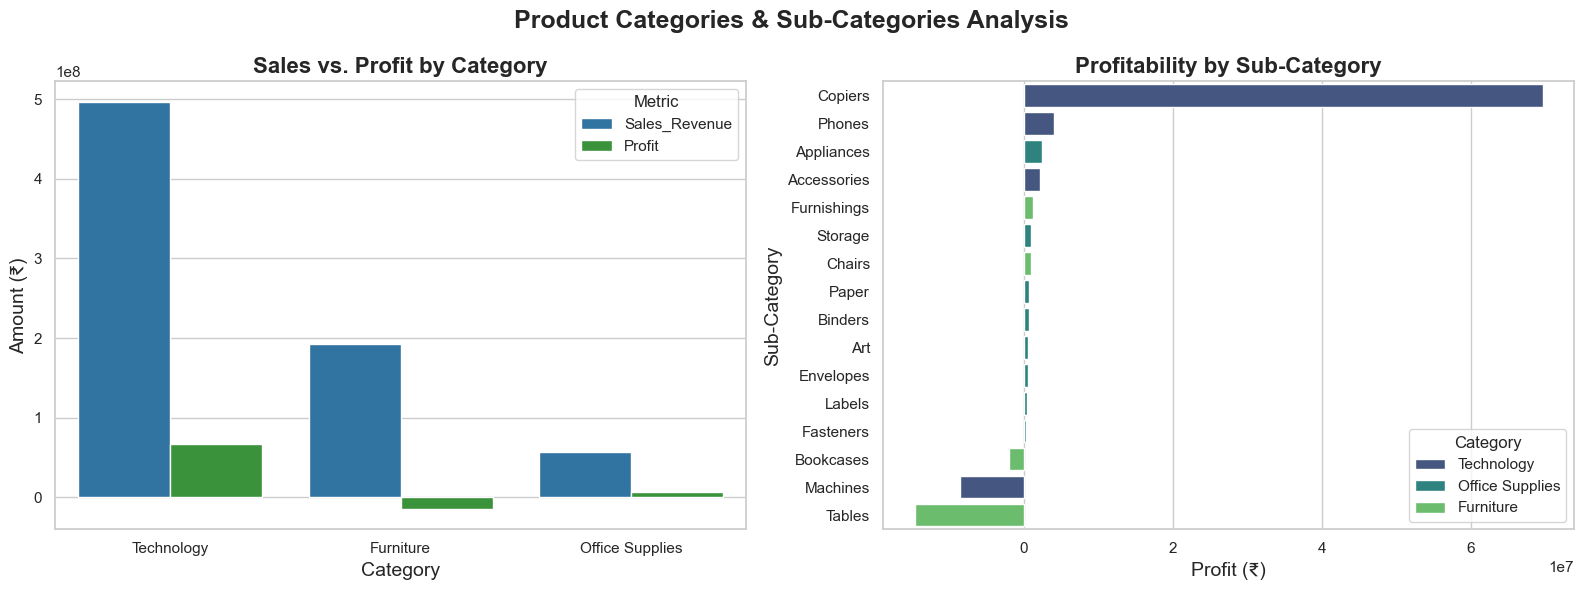

,Category,Sales_Revenue,Profit,Profit_Margin
2,Technology,4.965748e+08,67141340.23,13.520892
0,Furniture,1.918733e+08,-14583124.90,-7.600392
1,Office Supplies,5.709796e+07,6403801.92,11.215465


In [5]:
# Category performance
cat_df = df.groupby('Category').agg(
    Sales_Revenue=('Sales Revenue', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()
cat_df['Profit_Margin'] = (cat_df['Profit'] / cat_df['Sales_Revenue']) * 100
cat_df = cat_df.sort_values(by='Sales_Revenue', ascending=False)

# Sub-Category performance
subcat_df = df.groupby(['Category', 'Sub-Category']).agg(
    Sales_Revenue=('Sales Revenue', 'sum'),
    Profit=('Profit', 'sum')
).reset_index().sort_values(by='Profit', ascending=False)

# Visualize Category Performance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sales and Profit by Category
cat_melted = pd.melt(cat_df, id_vars=['Category'], value_vars=['Sales_Revenue', 'Profit'], var_name='Metric', value_name='Amount')
sns.barplot(data=cat_melted, x='Category', y='Amount', hue='Metric', palette=['#1f77b4', '#2ca02c'], ax=axes[0])
axes[0].set_title('Sales vs. Profit by Category', fontweight='bold')
axes[0].set_ylabel('Amount (₹)')
axes[0].set_xlabel('Category')

# Sub-category profitability
sns.barplot(data=subcat_df, x='Profit', y='Sub-Category', hue='Category', palette='viridis', ax=axes[1])
axes[1].set_title('Profitability by Sub-Category', fontweight='bold')
axes[1].set_xlabel('Profit (₹)')
axes[1].set_ylabel('Sub-Category')

plt.suptitle('Product Categories & Sub-Categories Analysis', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/category_analysis.png', dpi=300)
plt.show()

cat_df


## 5. Top 10 and Bottom 10 Products
* **Top 10 Products** are our primary revenue contributors and brand drivers.
* **Bottom 10 Products** are the most unprofitable products, indicating potential pricing or supply chain issues.


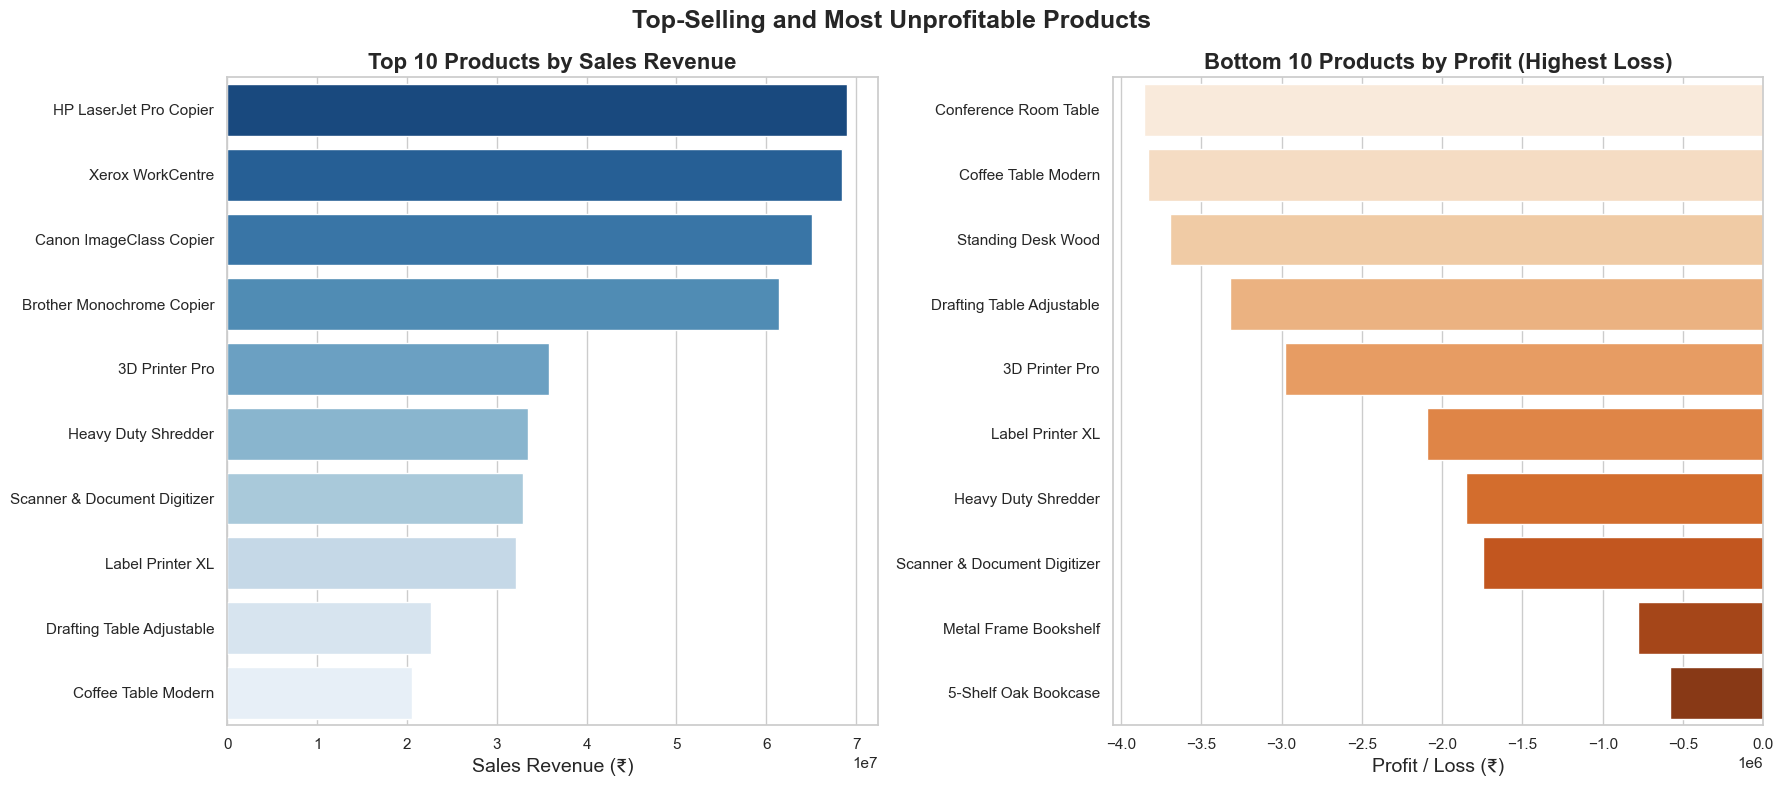

In [6]:
# Top 10 products by sales
top_prod = df.groupby('Product Name').agg(
    Sales_Revenue=('Sales Revenue', 'sum'),
    Profit=('Profit', 'sum')
).reset_index().sort_values(by='Sales_Revenue', ascending=False).head(10)

# Bottom 10 products by profit (most unprofitable)
bottom_prod = df.groupby('Product Name').agg(
    Sales_Revenue=('Sales Revenue', 'sum'),
    Profit=('Profit', 'sum')
).reset_index().sort_values(by='Profit', ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot Top 10 by Sales
sns.barplot(data=top_prod, x='Sales_Revenue', y='Product Name', palette='Blues_r', hue='Product Name', legend=False, ax=axes[0])
axes[0].set_title('Top 10 Products by Sales Revenue', fontweight='bold')
axes[0].set_xlabel('Sales Revenue (₹)')
axes[0].set_ylabel('')

# Plot Bottom 10 by Profit (losses)
sns.barplot(data=bottom_prod, x='Profit', y='Product Name', palette='Oranges', hue='Product Name', legend=False, ax=axes[1])
axes[1].set_title('Bottom 10 Products by Profit (Highest Loss)', fontweight='bold')
axes[1].set_xlabel('Profit / Loss (₹)')
axes[1].set_ylabel('')

plt.suptitle('Top-Selling and Most Unprofitable Products', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/product_performance.png', dpi=300)
plt.show()


## 6. Sales Distribution by Segment & Order Value
Understanding order sizes and customer segment behavior help in tailoring promotions.


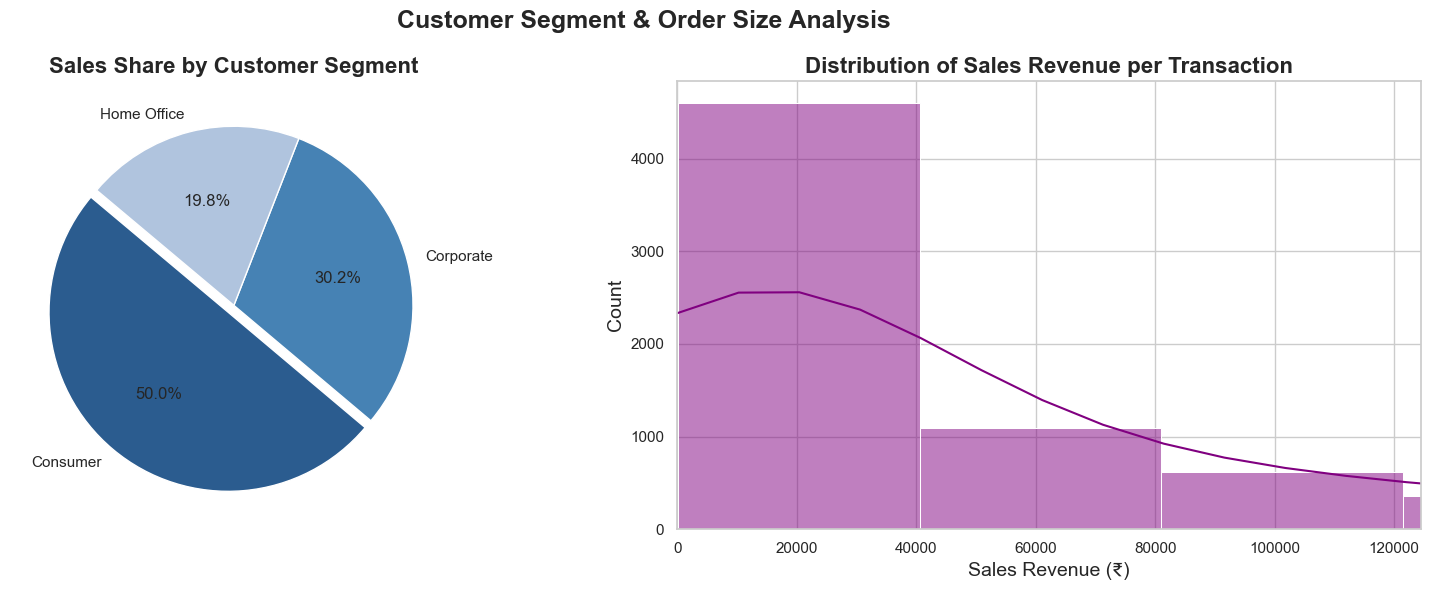

,Customer Segment,Sales_Revenue,Profit,Orders,Profit_Margin
0,Consumer,3.725652e+08,28531986.21,3973,7.658254
1,Corporate,2.254053e+08,18108753.25,2445,8.033862
2,Home Office,1.475756e+08,12321277.79,1582,8.349131


In [7]:
# Sales distribution by segment
segment_df = df.groupby('Customer Segment').agg(
    Sales_Revenue=('Sales Revenue', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'count')
).reset_index()
segment_df['Profit_Margin'] = (segment_df['Profit'] / segment_df['Sales_Revenue']) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sales Share by Customer Segment
axes[0].pie(segment_df['Sales_Revenue'], labels=segment_df['Customer Segment'], autopct='%1.1f%%', 
        colors=['#2b5c8f', '#4682b4', '#b0c4de'], startangle=140, explode=[0.05, 0, 0])
axes[0].set_title('Sales Share by Customer Segment', fontweight='bold')

# Distribution of Order Value
sns.histplot(data=df, x='Sales Revenue', bins=50, kde=True, color='purple', ax=axes[1])
axes[1].set_title('Distribution of Sales Revenue per Transaction', fontweight='bold')
axes[1].set_xlabel('Sales Revenue (₹)')
axes[1].set_xlim(0, 1500 * 83.0) # Scale limit to fit INR

plt.suptitle('Customer Segment & Order Size Analysis', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/sales_distribution.png', dpi=300)
plt.show()

segment_df


## 7. Strategic Business Insights

Let's address the core business questions based on our findings:

### 1. Which region generates the highest revenue?
* **Answer:** Based on the charts, the **West region** consistently generates the highest sales revenue, closely followed by the **East region**. The **South region** contributes the least.
* **Profitability:** Interestingly, while the West leads in sales volume, the East and West both show solid profitability, whereas the Central region suffers from significantly lower profit margins.

### 2. Which product categories are most profitable?
* **Answer:** **Technology** is the most profitable category, boasting the highest sales revenue and the highest profit margins (specifically subcategories like *Copiers* and *Phones*). 
* **Loss-makers:** **Furniture** is the least profitable category. In fact, subcategories like *Tables* and *Bookcases* regularly generate net losses due to heavy shipping costs, deep discounting, and lower markups.

### 3. Which products contribute most to sales?
* **Answer:** High-ticket Technology items (such as the *Canon ImageClass Copier*, *iPhone 15 Pro*, and *Samsung Galaxy S24*) and premium Furniture (*Executive Leather Chairs*) represent our top 10 products by sales.

### 4. Are there seasonal sales trends?
* **Answer:** Yes, there is clear seasonality. Sales peak sharply in **Q4 (November and December)**. This matches standard retail patterns (holiday shopping and year-end corporate budget flushing). There is also a secondary, smaller peak in **September** (back-to-school/work sales).

### 5. Which regions need improvement?
* **Answer:** The **Central region** needs the most urgent attention. Although it has a reasonable sales volume, its profit margin is extremely thin, likely driven by high logistics costs and aggressive discounting in competitive markets like Texas.

### 6. What factors impact profitability?
* **Answer:** 
  * **Product Mix:** High-margin technology categories boost overall profit margins, while furniture categories act as a drag.
  * **Discounts:** Discount levels above 20% severely erode margins and convert high-volume sales into net losses.
  * **Logistics & Geography:** Shipping large, bulky items (like desks and chairs) across long distances incurs high freight costs that eat up profit margins.
